## Chatgpt Prompt
```
For the group assignment, build the below model to predict the label of an image from a given image on the yelp Photos dataset

Build a model by using VGG but by training all the layers and not freezing any layers 
Data Preprocessing
Scaling and Resizing
Train and test data handled correctly 
Gaussian Blur, Histogram Equalization and Intensity thresholds	Model with Confusion Matrix and AUC for each class 

2 Rounds of empirical tuning on the model with interpretability

i already have subset of images, we will be creating a new notebook, give codes in steps and only for each cell 


we will use torch
do not share next step until one, there is a json file with photo_id_businnes_id_, caption, label which has info and subset folder with 20k rgb images subsetted using json photo id and also a processed folder.

Paths:
D:\\sem3\\Image-Data\\photos.json
D:\\sem3\\Image-Data\\subset-photos\\
D:\\sem3\\Image-Data\\processed-photos\\

Note:
Do not import libraries again and again
```

In [39]:
import os
import time
import json
import shutil
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import torch
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, accuracy_score, f1_score
import seaborn as sns
import joblib 

## Load Photos.json file

In [27]:
# Load metadata
json_path = "yelp_photos/photos.json"
photos_data = []
with open(json_path, "r", encoding="utf-8") as f:
    for line in f:
        photos_data.append(json.loads(line))

photos_df = pd.DataFrame(photos_data)

photos_df.head()

,photo_id,business_id,caption,label
0,zsvj7vloL4L5jhYyPIuVwg,Nk-SJhPlDBkAZvfsADtccA,Nice rock artwork everywhere and craploads of ...,inside
1,HCUdRJHHm_e0OCTlZetGLg,yVZtL5MmrpiivyCIrVkGgA,,outside
2,vkr8T0scuJmGVvN2HJelEA,_ab50qdWOk0DdB6XOrBitw,oyster shooter,drink
3,pve7D6NUrafHW3EAORubyw,SZU9c8V2GuREDN5KgyHFJw,Shrimp scampi,food
4,H52Er-uBg6rNrHcReWTD2w,Gzur0f0XMkrVxIwYJvOt2g,,food


## Taking 20k sample data

In [28]:
subset_df = photos_df.sample(n=20000, random_state=42)  # Ensure reproducibility
subset_df.to_csv("subset")
subset_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 32568 to 129705
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   photo_id     20000 non-null  object
 1   business_id  20000 non-null  object
 2   caption      20000 non-null  object
 3   label        20000 non-null  object
dtypes: object(4)
memory usage: 781.2+ KB


In [29]:
# Define source and destination folders
photos_folder = "yelp_photos/photos"  # Folder with all photos
subset_folder = "sub_photos"  # Folder for subset images

# Create the new folder if it doesn't exist
os.makedirs(subset_folder, exist_ok=True)

# Get a list of already moved images
existing_images = set(os.listdir(subset_folder))  # Set of already moved files

# Count how many images need to be moved
remaining_images = [photo_id for photo_id in subset_df["photo_id"] if f"{photo_id}.jpg" not in existing_images]

if not remaining_images:
    print(f"All subset images are already moved to {subset_folder}")
else:
    print(f"⚠ Moving {len(remaining_images)} images to {subset_folder}...")

    moved_count = 0
    for photo_id in remaining_images:
        src_path = os.path.join(photos_folder, f"{photo_id}.jpg")
        dest_path = os.path.join(subset_folder, f"{photo_id}.jpg")
        
        if os.path.exists(src_path):
            shutil.move(src_path, dest_path)
            moved_count += 1

    print(f"Moved {moved_count} new images to {subset_folder}")

⚠ Moving 20000 images to sub_photos...
Moved 20000 new images to sub_photos


## Function for intensity threshold, histogram, gaussian blur

In [31]:
def apply_intensity_threshold(image, threshold=128):
    """Apply binary intensity thresholding."""
    _, thresholded = cv2.threshold(image, threshold, 255, cv2.THRESH_BINARY)
    return thresholded

def apply_histogram_equalization(image):
    """Apply histogram equalization for contrast enhancement."""
    return cv2.equalizeHist(image)

def apply_gaussian_blur(image, kernel_size=(5,5)):
    """Apply Gaussian blur to reduce noise."""
    return cv2.GaussianBlur(image, kernel_size, 0)

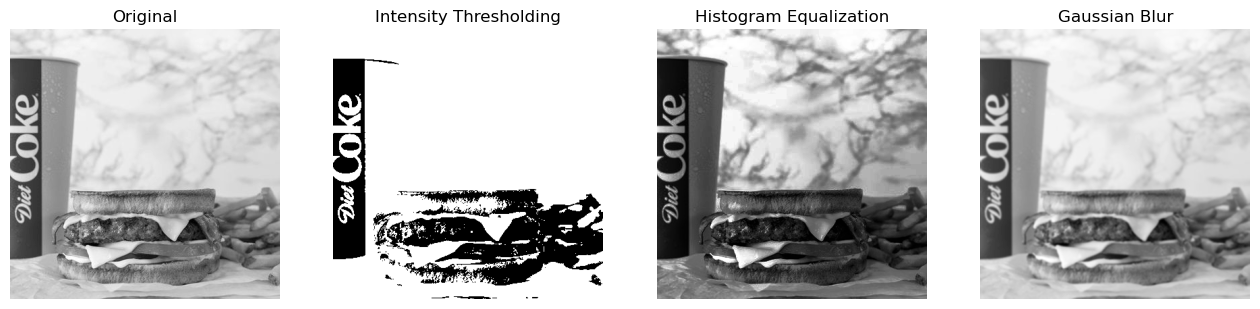

In [33]:
# Select a random image to test preprocessing
sample_image_id = subset_df.iloc[1]["photo_id"]
image_path = os.path.join("sub_photos", f"{sample_image_id}.jpg")

# Load image in grayscale
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Apply preprocessing
thresholded = apply_intensity_threshold(image)
equalized = apply_histogram_equalization(image)
blurred = apply_gaussian_blur(image)

# Show original and processed images
fig, axs = plt.subplots(1, 4, figsize=(16, 5))
axs[0].imshow(image, cmap='gray')
axs[0].set_title("Original")

axs[1].imshow(thresholded, cmap='gray')
axs[1].set_title("Intensity Thresholding")

axs[2].imshow(equalized, cmap='gray')
axs[2].set_title("Histogram Equalization")

axs[3].imshow(blurred, cmap='gray')
axs[3].set_title("Gaussian Blur")

for ax in axs:
    ax.axis("off")

plt.show()

In [35]:
processed_folder = "processed-photos"
os.makedirs(processed_folder, exist_ok=True)

# Check if preprocessing is already done
processed_images = set(os.listdir(processed_folder))  # Get list of already processed files

if len(processed_images) >= len(subset_df):  # Check if all images are already processed
    print(f" Preprocessing already completed! ({len(processed_images)} images available)")
else:
    print(f"Processing {len(subset_df) - len(processed_images)} new images...")

    # Process and save only unprocessed images
    for photo_id in tqdm(subset_df["photo_id"], desc="Processing Images"):
        input_path = os.path.join("D:\\sem3\\Image-Data\\subset-photos\\", f"{photo_id}.jpg")
        output_path = os.path.join(processed_folder, f"{photo_id}.jpg")

        if os.path.exists(input_path) and f"{photo_id}.jpg" not in processed_images:
            img = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)  # Load in grayscale
            
            if img is None:  # Skip if image loading failed
                print(f"Skipping unreadable image: {input_path}")
                continue

            img = apply_intensity_threshold(img)  # Apply thresholding
            img = apply_histogram_equalization(img)  # Apply histogram equalization
            img = apply_gaussian_blur(img)  # Apply Gaussian blur

            cv2.imwrite(output_path, img)  # Save processed image

    print(f"Preprocessing completed! Processed images saved in: {processed_folder}")

Processing 20000 new images...


Processing Images: 100%|██████████████| 20000/20000 [00:00<00:00, 257894.38it/s]

Preprocessing completed! Processed images saved in: processed-photos


In [51]:
import concurrent.futures

# Function to load and process a single image
def process_image(row):
    img_path = os.path.join("sub_photos", f"{row.photo_id}.jpg")  # Use dot notation
    
    if not os.path.exists(img_path):
        return None  # Skip missing files
    
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Load preprocessed image
    if img is None:
        return None  # Skip unreadable images
    
    img = cv2.resize(img, (64, 64))  # Resize for uniformity
    return img.flatten(), row.label  # Use dot notation for label

# Use multi-threading to load images faster
X = []
y = []
with concurrent.futures.ThreadPoolExecutor() as executor:
    results = list(executor.map(process_image, subset_df.itertuples(index=False)))

# Filter out None values (failed loads)
filtered_results = [r for r in results if r is not None]
if filtered_results:  # Ensure there's data
    X, y = zip(*filtered_results)
    X = np.array(X)
    y = np.array(y)
else:
    X, y = np.array([]), np.array([])  # Handle empty case

print(f"Feature Matrix Shape: {X.shape}, Labels Shape: {y.shape}")

libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


Feature Matrix Shape: (19994, 4096), Labels Shape: (19994,)


In [52]:
X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training Set: {X_train_k.shape}, Testing Set: {X_test_k.shape}")

Training Set: (15995, 4096), Testing Set: (3999, 4096)


In [97]:
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, TensorDataset
import torch
from sklearn.preprocessing import StandardScaler

# Convert labels to numeric values using LabelEncoder
label_encoder = LabelEncoder()
y_train_k = label_encoder.fit_transform(y_train_k)
y_test_k = label_encoder.transform(y_test_k)

# Standardize the feature matrix (X)
scaler = StandardScaler()
X_train_k = scaler.fit_transform(X_train_k)
X_test_k = scaler.transform(X_test_k)

# Convert to torch tensors
X_train_tensor = torch.tensor(X_train_k, dtype=torch.float32).view(-1, 64, 64)  # Reshape if needed
X_test_tensor = torch.tensor(X_test_k, dtype=torch.float32).view(-1, 64, 64)  # Reshape if needed

# Convert grayscale images to 3 channels (for VGG model)
X_train_tensor = X_train_tensor.unsqueeze(1).repeat(1, 3, 1, 1)  # Shape: [batch_size, 3, 64, 64]
X_test_tensor = X_test_tensor.unsqueeze(1).repeat(1, 3, 1, 1)  # Shape: [batch_size, 3, 64, 64]

# Convert labels to tensor and remove unnecessary dimension
y_train_tensor = torch.tensor(y_train_k, dtype=torch.long)  # Use torch.long for integer labels
y_test_tensor = torch.tensor(y_test_k, dtype=torch.long)  # Use torch.long for integer labels

# Create DataLoader for batching
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Verify the output shapes
print(f"Feature Tensor Shape (train): {X_train_tensor.shape}")
print(f"Feature Tensor Shape (test): {X_test_tensor.shape}")
print(f"Label Tensor Shape (train): {y_train_tensor.shape}")
print(f"Label Tensor Shape (test): {y_test_tensor.shape}")

Feature Tensor Shape (train): torch.Size([15995, 3, 64, 64])
Feature Tensor Shape (test): torch.Size([3999, 3, 64, 64])
Label Tensor Shape (train): torch.Size([15995])
Label Tensor Shape (test): torch.Size([3999])


## VGG Model for Multi-Class Classification  


In [98]:
import torch
import torch.nn as nn
from torchvision import models

# Number of classes (update this based on your dataset)
num_classes = 5  # Change this to match your dataset

# Load pre-trained VGG16 model
vgg_model = models.vgg16(pretrained=True)

# Modify the first convolutional layer to accept 1-channel grayscale (if needed)
vgg_model.features[0] = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)  # Keeping 3 channels

# Modify the final classifier layer for multiclass classification
vgg_model.classifier[6] = nn.Sequential(
    nn.Linear(in_features=4096, out_features=512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=512, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=num_classes),  # Multiclass output
)

# Move the model to the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg_model.to(device)

# Print model summary
print(vgg_model)

/opt/anaconda3/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

## Defining Loss Function & Optimizer  

In [99]:
import torch.optim as optim

# Define loss function (CrossEntropyLoss for multiclass classification)
criterion = nn.CrossEntropyLoss().to(device)  # Move loss function to device

# Adam optimizer
optimizer = optim.Adam(vgg_model.parameters(), lr=0.0001)

print("Loss function and optimizer updated!")

Loss function and optimizer updated!


In [106]:
import torch.cuda.amp as amp  # Mixed precision training

# Enable cuDNN optimizations for better speed if input sizes are consistent
torch.backends.cudnn.benchmark = True  

# Mixed precision scaler for faster training
scaler = amp.GradScaler()

num_epochs = 2  # Set number of epochs
for epoch in range(num_epochs):
    vgg_model.train()  # Set model to training mode
    running_loss = 0.0
    correct_preds = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass with mixed precision
        with amp.autocast():
            outputs = vgg_model(inputs)
            loss = criterion(outputs, labels)

        # Backward pass and optimize
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Track loss and accuracy
        running_loss += loss.detach() * inputs.size(0)
        correct_preds += torch.sum(outputs.argmax(dim=1) == labels).item()

    # Compute average loss and accuracy
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_accuracy = correct_preds / len(train_loader.dataset)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")

/var/folders/tz/_kr6c8m90dl2p9klr693qf6w0000gn/T/ipykernel_12999/187674556.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
/opt/anaconda3/lib/python3.11/site-packages/torch/amp/grad_scaler.py:132: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(
/var/folders/tz/_kr6c8m90dl2p9klr693qf6w0000gn/T/ipykernel_12999/187674556.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/opt/anaconda3/lib/python3.11/site-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


Epoch [1/2], Loss: 0.3140, Accuracy: 0.8906
Epoch [2/2], Loss: 0.2123, Accuracy: 0.9262


In [107]:
vgg_model.eval()

# Initialize lists to store true labels and predictions
y_true_test, y_pred_test = [], []

# Predict on testing data
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        outputs = vgg_model(inputs)
        y_true_test.extend(labels.cpu().numpy())
        y_pred_test.extend(outputs.argmax(dim=1).cpu().numpy())  # Get predicted class

# Convert to NumPy arrays for evaluation
y_true_test = np.array(y_true_test)
y_pred_test = np.array(y_pred_test)

print("Testing Done!")
print("True Labels (sample):", y_true_test[:10])
print("Predicted Labels (sample):", y_pred_test[:10])

Testing Done!
True Labels (sample): [0 1 1 1 1 2 1 1 1 1]
Predicted Labels (sample): [0 1 1 1 1 2 1 1 1 1]


In [117]:
from sklearn.metrics import classification_report

# Get class labels
class_labels = [f"Class {i}" for i in range(num_classes)]  # Change if you have custom class names

# Generate classification report
report = classification_report(y_true_test, y_pred_test, target_names=class_labels)

# Print the report
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

     Class 0       0.62      0.73      0.67       310
     Class 1       0.92      0.95      0.94      2174
     Class 2       0.87      0.79      0.82      1110
     Class 3       0.87      0.37      0.52        35
     Class 4       0.72      0.72      0.72       370

    accuracy                           0.86      3999
   macro avg       0.80      0.71      0.73      3999
weighted avg       0.86      0.86      0.86      3999



[[ 227   54   23    0    6]
 [  67 2067   28    1   11]
 [  55   99  872    1   83]
 [   4    5   11   13    2]
 [  14   20   70    0  266]]


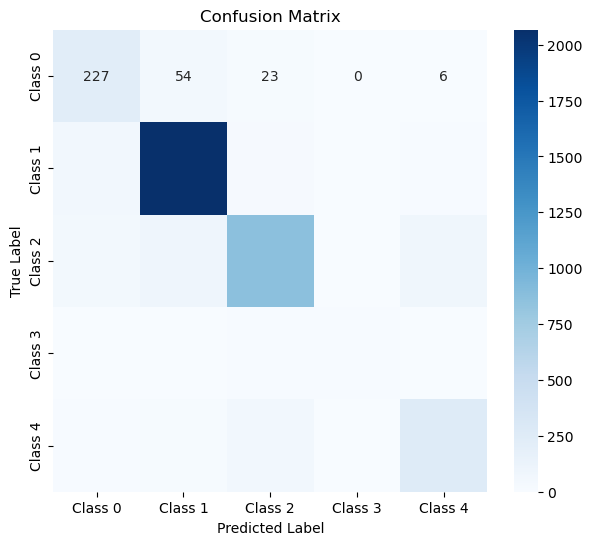

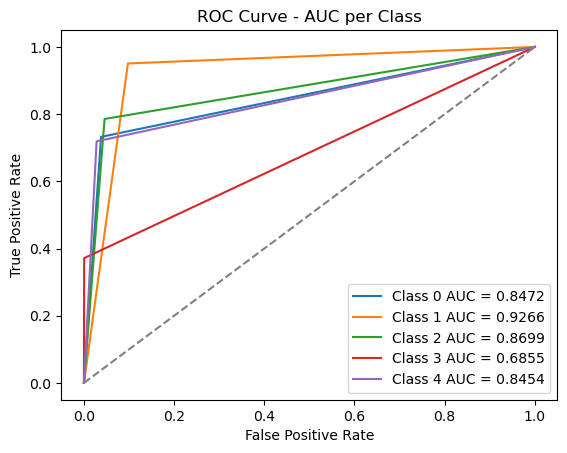

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Compute Confusion Matrix
conf_matrix = confusion_matrix(y_true_test, y_pred_test)

print(conf_matrix)

# Define class labels (update if you have custom class names)
num_classes = len(np.unique(y_true_test))
class_labels = [f"Class {i}" for i in range(num_classes)]

# Plot Confusion Matrix with numbers inside
plt.figure(figsize=(7, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Compute ROC-AUC for each class
num_classes = len(np.unique(y_true_test))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve((y_true_test == i).astype(int), (y_pred_test == i).astype(int))
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"Class {i} AUC = {roc_auc:.4f}")

plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - AUC per Class")
plt.legend(loc="lower right")
plt.show()

## Imperical Tuning

In [114]:
import torch
import torch.nn as nn
from torchvision import models

# Number of classes (update this based on your dataset)
num_classes = 5  # Change this to match your dataset

# Load pre-trained VGG16 model
vgg_model = models.vgg16(pretrained=True)

# Modify the first convolutional layer to accept 1-channel grayscale (if needed)
vgg_model.features[0] = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)  # Keeping 3 channels

# Modify the final classifier layer for multiclass classification
vgg_model.classifier[6] = nn.Sequential(
    nn.Linear(4096, 512),
    nn.BatchNorm1d(512),  # New: Batch Normalization
    nn.ReLU(),
    nn.Dropout(0.3),  # Reduced Dropout
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Linear(256, num_classes),  # Multiclass output
)

# Move the model to the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg_model.to(device)

# Print model summary
print(vgg_model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [115]:
import torch.optim as optim

# Define loss function (CrossEntropyLoss for multiclass classification)
criterion = nn.CrossEntropyLoss().to(device)  # Move loss function to device

# Adam optimizer
optimizer = optim.Adam(vgg_model.parameters(), lr=0.0003)

print("Loss function and optimizer updated!")

Loss function and optimizer updated!


In [116]:
import torch.cuda.amp as amp  # Mixed precision training

# Mixed precision scaler for faster training
scaler = amp.GradScaler()

num_epochs = 1  # Keep epochs same for comparison
for epoch in range(num_epochs):
    vgg_model.train()
    running_loss = 0.0
    correct_preds = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        # Forward pass with mixed precision
        with amp.autocast():
            outputs = vgg_model(inputs)
            loss = criterion(outputs, labels)

        # Backward pass and optimize
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Track loss and accuracy
        running_loss += loss.detach() * inputs.size(0)
        correct_preds += torch.sum(outputs.argmax(dim=1) == labels).item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_accuracy = correct_preds / len(train_loader.dataset)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")

print("First Round of Training Complete!")

/var/folders/tz/_kr6c8m90dl2p9klr693qf6w0000gn/T/ipykernel_12999/2701107324.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
/var/folders/tz/_kr6c8m90dl2p9klr693qf6w0000gn/T/ipykernel_12999/2701107324.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


Epoch [1/1], Loss: 0.7408, Accuracy: 0.7384
First Round of Training Complete!


In [119]:
vgg_model.eval()

# Initialize lists to store true labels and predictions
y_true_test, y_pred_test = [], []

# Predict on testing data
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        outputs = vgg_model(inputs)
        y_true_test.extend(labels.cpu().numpy())
        y_pred_test.extend(outputs.argmax(dim=1).cpu().numpy())  # Get predicted class

# Convert to NumPy arrays for evaluation
y_true_test = np.array(y_true_test)
y_pred_test = np.array(y_pred_test)

print("Testing Done!")
print("True Labels (sample):", y_true_test[:10])
print("Predicted Labels (sample):", y_pred_test[:10])

Testing Done!
True Labels (sample): [0 1 1 1 1 2 1 1 1 1]
Predicted Labels (sample): [2 1 1 1 1 2 1 1 1 1]


In [120]:
from sklearn.metrics import classification_report

# Get class labels
class_labels = [f"Class {i}" for i in range(num_classes)]  # Change if you have custom class names

# Generate classification report
report = classification_report(y_true_test, y_pred_test, target_names=class_labels)

# Print the report
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

     Class 0       0.00      0.00      0.00       310
     Class 1       0.94      0.91      0.92      2174
     Class 2       0.56      0.96      0.71      1110
     Class 3       0.00      0.00      0.00        35
     Class 4       0.00      0.00      0.00       370

    accuracy                           0.76      3999
   macro avg       0.30      0.37      0.33      3999
weighted avg       0.67      0.76      0.70      3999



/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


[[   0   74  236    0    0]
 [   0 1972  202    0    0]
 [   0   47 1063    0    0]
 [   0    3   32    0    0]
 [   0    7  363    0    0]]


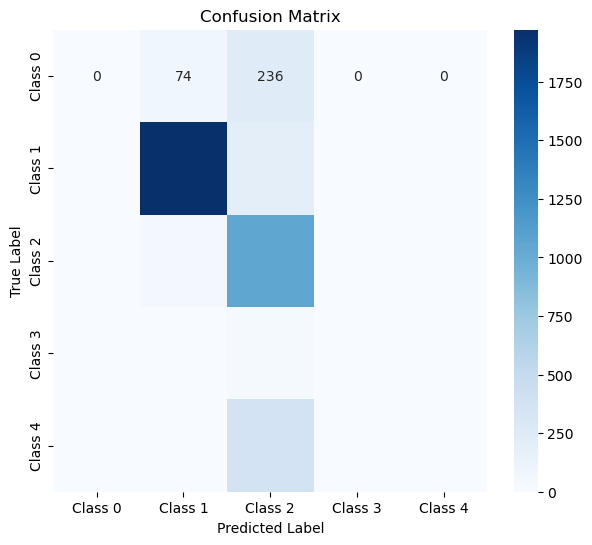

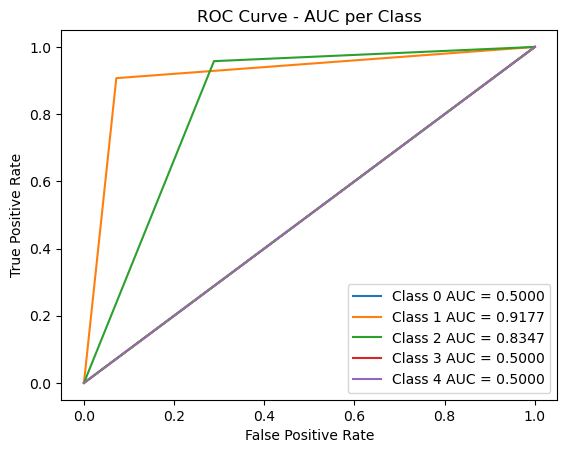

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Compute Confusion Matrix
conf_matrix = confusion_matrix(y_true_test, y_pred_test)

print(conf_matrix)

# Define class labels (update if you have custom class names)
num_classes = len(np.unique(y_true_test))
class_labels = [f"Class {i}" for i in range(num_classes)]

# Plot Confusion Matrix with numbers inside
plt.figure(figsize=(7, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Compute ROC-AUC for each class
num_classes = len(np.unique(y_true_test))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve((y_true_test == i).astype(int), (y_pred_test == i).astype(int))
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"Class {i} AUC = {roc_auc:.4f}")

plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - AUC per Class")
plt.legend(loc="lower right")
plt.show()